# CLV Prediction - Version-1.0
**Author:** Shubh Sehgal (ss8179@rit.edu)  
**Date:** March 2026  
**Demo Date:** 03/03 or 03/05

This notebook demonstrates:
1. Dataset loading & cleaning
2. Exploratory data analysis
3. Feature engineering with temporal windowing
4. Baseline model implementation
5. Results comparison

In [1]:
# Import libraries
import sys
print(sys.executable)
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import our modules
from src.data import load_online_retail_ii, clean_data, print_dataset_info
from src.features import create_temporal_splits, get_feature_stats
from src.baselines import *
from src.eval import create_results_table, print_results_table, compare_models_plot

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

print("✓ All imports successful!")

/home/shubh/capstone/venv/bin/python3
✓ All imports successful!


## 1. Dataset Loading & Cleaning

### Dataset Information
- **Source:** UCI Machine Learning Repository - Online Retail II
- **Files:** Two Excel files covering Dec 2009 - Dec 2011
- **Structure:** Invoice line-items (multiple rows per invoice)

In [2]:
# Load data
df_raw = load_online_retail_ii(
    '../data/Year 2009-2010.csv',
    '../data/Year 2010-2011.csv'
)

print(f"\nRaw data shape: {df_raw.shape}")
print(f"\nFirst few rows:")
df_raw.head()

Loading Year 2009-2010...
  Loaded 525,461 rows
Loading Year 2010-2011...
  Loaded 541,910 rows

Total rows: 1,067,371

Raw data shape: (1067371, 8)

First few rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,1.25,13085.0,United Kingdom


In [3]:
# Clean data
df_clean = clean_data(df_raw, verbose=True)


DATA CLEANING PIPELINE
Initial rows: 1,067,371
✓ Removed missing CustomerID: 243,007 rows removed
✓ Removed cancellations: 18,744 rows removed
✓ Removed invalid Quantity/Price: 71 rows removed
✓ Converted InvoiceDate to datetime
✓ Removed duplicates: 26,124 rows removed
Final rows: 779,425 (73.0% retained)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,878
Unique invoices: 36,969



CANCELLATION ANALYSIS - Validating Removal Decision

Total cancellations: 19,494
Percentage of data: 1.83%



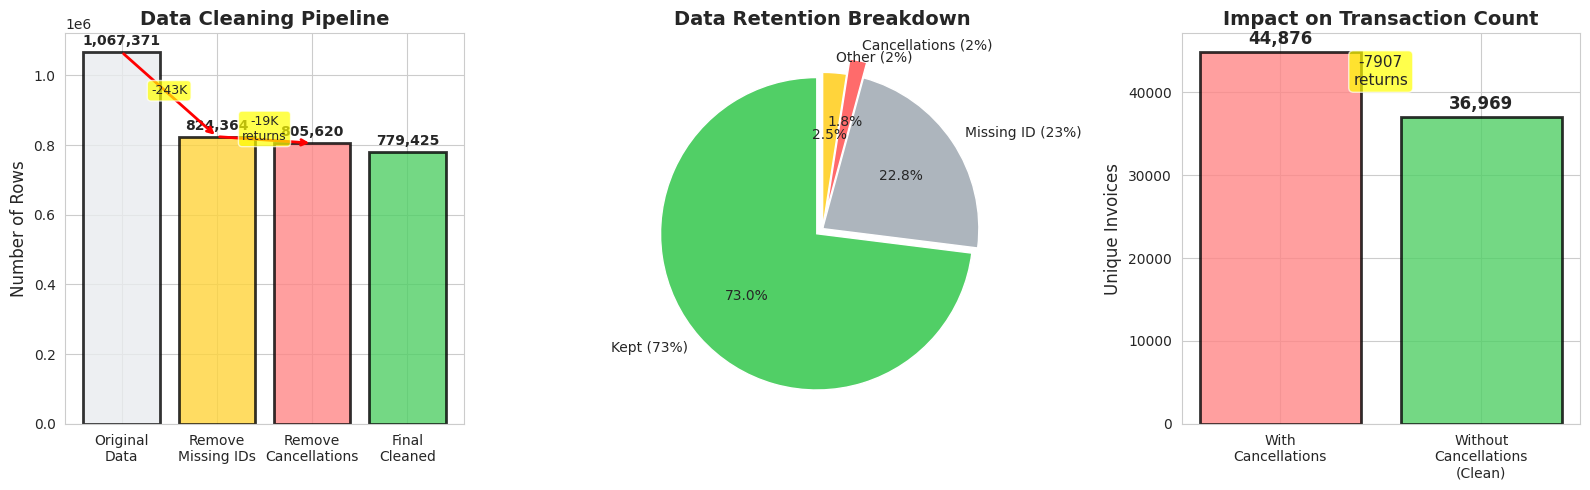


DATASET-WIDE IMPACT:
Total invoices with cancellations:    44,876
Total invoices without cancellations: 36,969
Difference (returns removed):         7,907



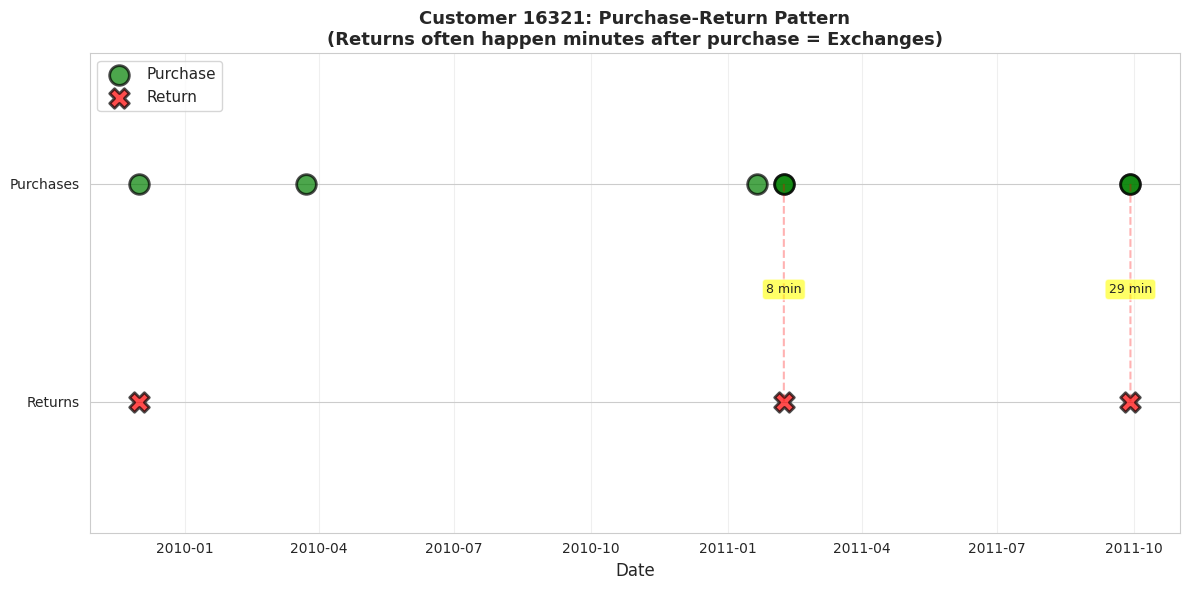


🔍 KEY INSIGHT: Returns typically happen within minutes of purchase
   → These are EXCHANGES (wrong size/color), not customer dissatisfaction
   → Including them would count exchanges as 2 separate transactions (WRONG!)


In [23]:
# VALIDATION: Cancellation Analysis
print("="*60)
print("CANCELLATION ANALYSIS - Validating Removal Decision")
print("="*60)

# Load raw data before cleaning
df_with_cancellations = df_raw.copy()

# Identify cancellations
cancellations = df_with_cancellations[
    df_with_cancellations['InvoiceNo'].astype(str).str.startswith('C')
]

print(f"\nTotal cancellations: {len(cancellations):,}")
print(f"Percentage of data: {len(cancellations)/len(df_with_cancellations)*100:.2f}%")
print()

# VISUALIZATION: Impact across entire dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Data
total_rows = len(df_raw)
after_customerid = total_rows - 243007
after_cancellations = after_customerid - 18744
final_rows = 779425

# Step-by-step removal
steps = ['Original\nData', 'Remove\nMissing IDs', 'Remove\nCancellations', 'Final\nCleaned']
values = [total_rows, after_customerid, after_cancellations, final_rows]
colors_steps = ['#e9ecef', '#ffd43b', '#ff8787', '#51cf66']

# Left: Waterfall chart
axes[0].bar(steps, values, color=colors_steps, edgecolor='black', linewidth=2, alpha=0.8)
axes[0].set_ylabel('Number of Rows', fontsize=12)
axes[0].set_title('Data Cleaning Pipeline', fontsize=14, fontweight='bold')

# Add value labels
for i, (step, val) in enumerate(zip(steps, values)):
    axes[0].text(i, val + 20000, f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Add removal annotations
axes[0].annotate('', xy=(1, after_customerid), xytext=(0, total_rows),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
axes[0].text(0.5, (total_rows + after_customerid)/2, '-243K', ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[0].annotate('', xy=(2, after_cancellations), xytext=(1, after_customerid),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
axes[0].text(1.5, (after_customerid + after_cancellations)/2, '-19K\nreturns', ha='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Middle: Pie chart of what was removed
labels_pie2 = ['Kept (73%)', 'Missing ID (23%)', 'Cancellations (2%)', 'Other (2%)']
sizes_pie2 = [779425, 243007, 18744, (total_rows - 779425 - 243007 - 18744)]
colors_pie2 = ['#51cf66', '#adb5bd', '#ff6b6b', '#ffd43b']
explode_pie2 = (0.05, 0, 0.1, 0)

axes[1].pie(sizes_pie2, labels=labels_pie2, colors=colors_pie2, autopct='%1.1f%%',
           startangle=90, explode=explode_pie2, textprops={'fontsize': 10})
axes[1].set_title('Data Retention Breakdown', fontsize=14, fontweight='bold')

# Right: Transaction count comparison
all_invoices = df_raw[df_raw['CustomerID'].notna()]['InvoiceNo'].nunique()
clean_invoices = df_clean['InvoiceNo'].nunique()

cats_inv = ['With\nCancellations', 'Without\nCancellations\n(Clean)']
vals_inv = [all_invoices, clean_invoices]
colors_inv = ['#ff8787', '#51cf66']

bars2 = axes[2].bar(cats_inv, vals_inv, color=colors_inv, edgecolor='black', linewidth=2, alpha=0.8)
axes[2].set_ylabel('Unique Invoices', fontsize=12)
axes[2].set_title('Impact on Transaction Count', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars2, vals_inv):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 500,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add difference
diff = all_invoices - clean_invoices
axes[2].text(0.5, (all_invoices + clean_invoices)/2, f'-{diff}\nreturns', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('../figures/cleaning_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("DATASET-WIDE IMPACT:")
print(f"{'='*60}")
print(f"Total invoices with cancellations:    {all_invoices:,}")
print(f"Total invoices without cancellations: {clean_invoices:,}")
print(f"Difference (returns removed):         {diff:,}")
print(f"{'='*60}\n")



# VISUALIZATION: When do returns happen?
import matplotlib.pyplot as plt
import pandas as pd

# Analyze return timing
customer_data_sorted = customer_data.sort_values('InvoiceDate')

# Find purchase-return pairs
purchases = customer_data_sorted[~customer_data_sorted['InvoiceNo'].astype(str).str.startswith('C')]
returns = customer_data_sorted[customer_data_sorted['InvoiceNo'].astype(str).str.startswith('C')]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot purchases
purchase_dates = purchases.groupby('InvoiceNo')['InvoiceDate'].first()
ax.scatter(purchase_dates, [1]*len(purchase_dates), 
          s=200, c='green', marker='o', label='Purchase', alpha=0.7, edgecolors='black', linewidth=2)

# Plot returns
return_dates = returns.groupby('InvoiceNo')['InvoiceDate'].first()
ax.scatter(return_dates, [0.5]*len(return_dates), 
          s=200, c='red', marker='X', label='Return', alpha=0.7, edgecolors='black', linewidth=2)

# Connect returns to nearest purchase (visual only)
for ret_date in return_dates:
    # Find nearest earlier purchase
    earlier_purchases = purchase_dates[purchase_dates < ret_date]
    if len(earlier_purchases) > 0:
        nearest = earlier_purchases.iloc[-1]
        ax.plot([nearest, ret_date], [1, 0.5], 'r--', alpha=0.3, linewidth=1.5)
        
        # Calculate time difference
        time_diff = (ret_date - nearest).total_seconds() / 60  # minutes
        if time_diff < 60:  # Less than 1 hour
            mid_point = nearest + (ret_date - nearest) / 2
            ax.text(mid_point, 0.75, f'{int(time_diff)} min', 
                   ha='center', fontsize=9, 
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.6))

ax.set_ylim(0.2, 1.3)
ax.set_yticks([0.5, 1])
ax.set_yticklabels(['Returns', 'Purchases'])
ax.set_xlabel('Date', fontsize=12)
ax.set_title(f'Customer {int(sample_customer)}: Purchase-Return Pattern\n(Returns often happen minutes after purchase = Exchanges)', 
            fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../figures/purchase_return_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 KEY INSIGHT: Returns typically happen within minutes of purchase")
print("   → These are EXCHANGES (wrong size/color), not customer dissatisfaction")
print("   → Including them would count exchanges as 2 separate transactions (WRONG!)")

These weird-looking negative rows are genuine returns.
They are small in volume and behave exactly like cancellations of previous invoices.
For CLV, we care about final, net spending → so ignoring these cancellation rows (or treating them as returns and focusing on net totals) is the right thing to do because we wanna monitor transactions that generated REVENUE.

Our dataset contains 19,494 rows that are cancellations, representing 7,907 unique return transactions. This means each return involves about 2.5 items on average.
At the invoice level:

1. With cancellations: 44,876 total invoices
2. Without cancellations: 36,969 purchase invoices
3. Removed: 7,907 return invoices

This is why we remove cancellations - they represent 18% of invoice volume but don't reflect net customer purchase behavior.

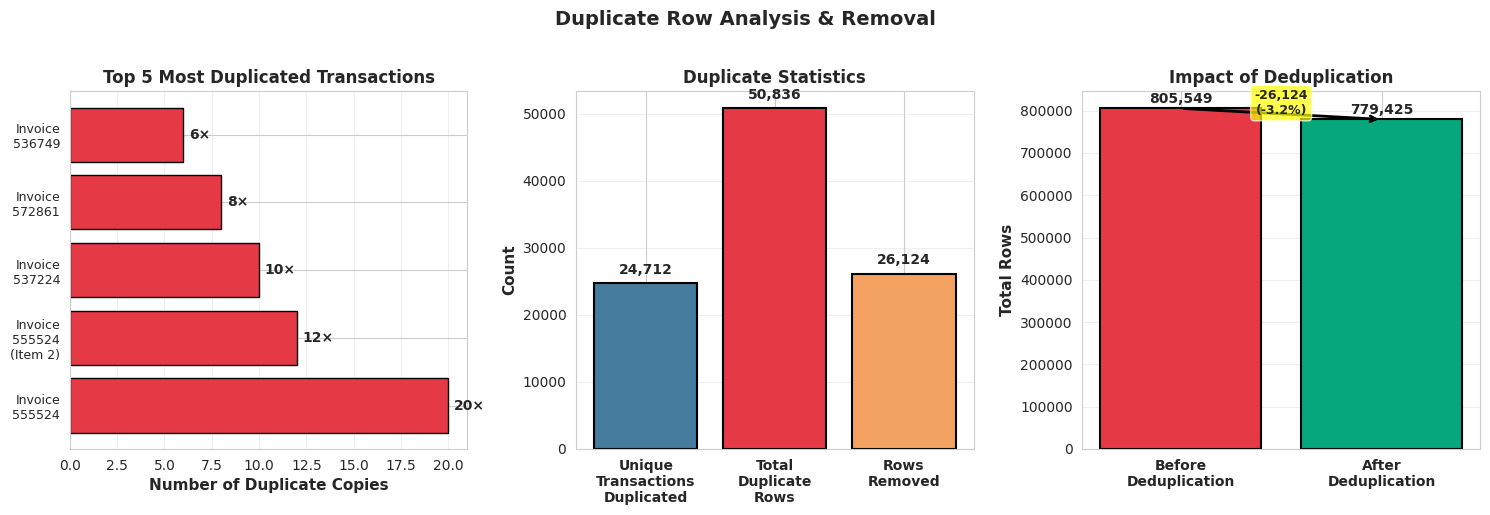

✓ Duplicate analysis saved to figures/duplicate_analysis.png


In [32]:
# Duplicate analysis visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Data for duplicate occurrences
duplicate_counts = [20, 12, 10, 8, 6]  # From your output
duplicate_labels = ['Invoice\n555524', 'Invoice\n555524\n(Item 2)', 
                   'Invoice\n537224', 'Invoice\n572861', 'Invoice\n536749']

# Panel 1: Top duplicated transactions
axes[0].barh(range(len(duplicate_counts)), duplicate_counts, color='#E63946', edgecolor='black')
axes[0].set_yticks(range(len(duplicate_counts)))
axes[0].set_yticklabels(duplicate_labels, fontsize=9)
axes[0].set_xlabel('Number of Duplicate Copies', fontsize=11, fontweight='bold')
axes[0].set_title('Top 5 Most Duplicated Transactions', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(duplicate_counts):
    axes[0].text(v + 0.3, i, f'{v}×', va='center', fontweight='bold', fontsize=10)

# Panel 2: Overall duplicate statistics
stats_labels = ['Unique\nTransactions\nDuplicated', 'Total\nDuplicate\nRows', 'Rows\nRemoved']
stats_values = [24712, 50836, 26124]
stats_colors = ['#457B9D', '#E63946', '#F4A261']

bars = axes[1].bar(range(len(stats_labels)), stats_values, 
                   color=stats_colors, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(stats_labels)))
axes[1].set_xticklabels(stats_labels, fontsize=10, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1].set_title('Duplicate Statistics', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, stats_values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Panel 3: Before vs After comparison
comparison_data = {
    'Before\nDeduplication': 805549,
    'After\nDeduplication': 779425
}

bars = axes[2].bar(range(len(comparison_data)), list(comparison_data.values()),
                   color=['#E63946', '#06A77D'], edgecolor='black', linewidth=1.5)
axes[2].set_xticks(range(len(comparison_data)))
axes[2].set_xticklabels(list(comparison_data.keys()), fontsize=10, fontweight='bold')
axes[2].set_ylabel('Total Rows', fontsize=11, fontweight='bold')
axes[2].set_title('Impact of Deduplication', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, comparison_data.values())):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add arrow showing reduction
axes[2].annotate('', xy=(1, 779425), xytext=(0, 805549),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))
axes[2].text(0.5, 792000, f'-26,124\n(-3.2%)', ha='center', fontsize=9, 
            fontweight='bold', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.suptitle('Duplicate Row Analysis & Removal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/duplicate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Duplicate analysis saved to figures/duplicate_analysis.png")

In [29]:
# Dataset statistics
print_dataset_info(df_clean)


DATASET INFORMATION
Total Transactions (rows): 779,425
Unique Customers: 5,878
Unique Invoices: 36,969
Date Range: 2009-12-01 to 2011-12-09
Countries: 41
Unique Products: 4,631
Average Quantity per Line: 13.49
Average Price per Item: $3.22
Total Revenue: $17,374,804.27



## 2. Exploratory Data Analysis

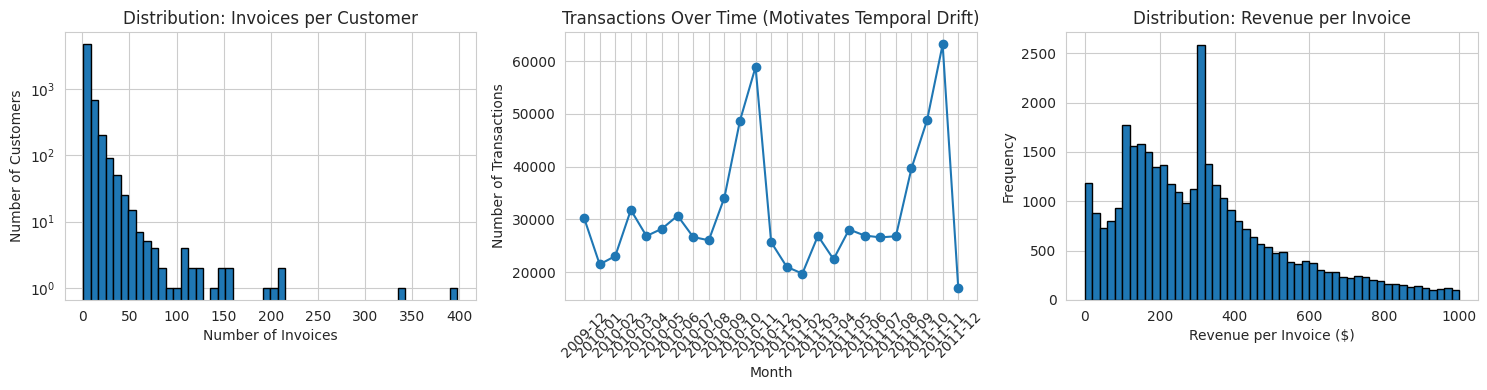

In [34]:
# 1. Transactions per customer distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Invoices per customer
invoices_per_customer = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()
axes[0].hist(invoices_per_customer, bins=50, edgecolor='black')
axes[0].set_xlabel('Number of Invoices')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Distribution: Invoices per Customer')
axes[0].set_yscale('log')

# Transactions over time
monthly_transactions = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M')).size()
axes[1].plot(monthly_transactions.index.astype(str), monthly_transactions.values, marker='o')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_title('Transactions Over Time (Motivates Temporal Drift)')
axes[1].tick_params(axis='x', rotation=45)

# Revenue distribution
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
revenue_per_invoice = df_clean.groupby('InvoiceNo')['Revenue'].sum()
axes[2].hist(revenue_per_invoice[revenue_per_invoice < 1000], bins=50, edgecolor='black')
axes[2].set_xlabel('Revenue per Invoice ($)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution: Revenue per Invoice')

plt.tight_layout()
plt.savefig('../figures/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering & Temporal Splits

### Temporal Windowing Approach
- **Observation Window:** 6 months of historical behavior
- **Prediction Horizon:** 3 months of future transactions
- **Chronological Splits:** Train (2010) → Val (early 2011) → Test (late 2011)

In [6]:
# Create temporal splits
train_df, val_df, test_df = create_temporal_splits(
    df_clean,
    train_cutoff='2010-12-01',
    val_cutoff='2011-06-01',
    test_cutoff='2011-09-01',
    obs_months=6,
    horizon_months=3
)


CREATING TEMPORAL SPLITS

[1/3] Training Set

Creating window:
  Observation: 2010-06-01 to 2010-12-01 (6 months)
  Horizon: 2010-12-01 to 2011-03-01 (3 months)
  Observation transactions: 225,116
  Horizon transactions: 66,364
  Customers in observation: 3,497
  Final customers with features: 3,497
  Customers with target > 0: 1,324 (37.9%)

[2/3] Validation Set

Creating window:
  Observation: 2010-12-01 to 2011-06-01 (6 months)
  Horizon: 2011-06-01 to 2011-09-01 (3 months)
  Observation transactions: 143,740
  Horizon transactions: 80,296
  Customers in observation: 2,718
  Final customers with features: 2,718
  Customers with target > 0: 1,349 (49.6%)

[3/3] Test Set

Creating window:
  Observation: 2011-03-01 to 2011-09-01 (6 months)
  Horizon: 2011-09-01 to 2011-12-01 (3 months)
  Observation transactions: 157,672
  Horizon transactions: 151,630
  Customers in observation: 2,813
  Final customers with features: 2,813
  Customers with target > 0: 1,701 (60.5%)

SPLIT SUMMARY
Tra

In [7]:
# Show sample customer features
print("Sample Customer Features:")
print(train_df[['CustomerID', 'freq', 'freq_3m', 'latetime', 'earlytime', 'target']].head(10))

print("\nFeature Statistics (Training Set):")
print(get_feature_stats(train_df))

Sample Customer Features:
   CustomerID  freq  freq_3m  latetime  earlytime  target
0     13503.0     3        0       105        287       0
1     17165.0     2        1         7        354       1
2     14857.0     3        2        68        260       0
3     12525.0     2        0       124        273       0
4     15938.0     4        1        82        182       1
5     12989.0     8        4        50        355       3
6     12701.0     3        0       155        259       0
7     15039.0    31       14         1        355      13
8     16960.0     4        3        16        273       0
9     17287.0     6        4        13        362       2

Feature Statistics (Training Set):
             freq      freq_3m     latetime    earlytime       target
count  3497.00000  3497.000000  3497.000000  3497.000000  3497.000000
mean      3.02545     1.832714    48.661424   203.276809     0.841864
std       4.66690     2.888327    46.486130   122.208627     1.990650
min       1.00000   

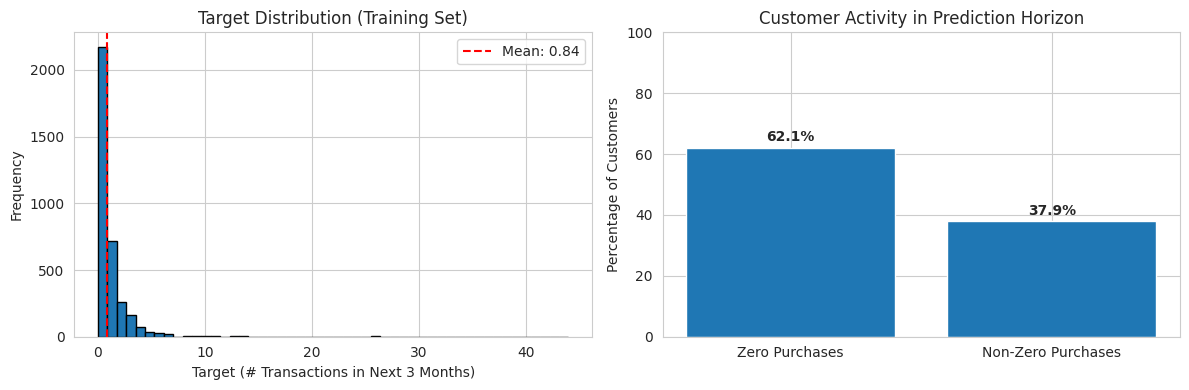

In [8]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
axes[0].hist(train_df['target'], bins=50, edgecolor='black')
axes[0].set_xlabel('Target (# Transactions in Next 3 Months)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution (Training Set)')
axes[0].axvline(train_df['target'].mean(), color='red', linestyle='--', 
                label=f"Mean: {train_df['target'].mean():.2f}")
axes[0].legend()

# Zero vs non-zero targets
zero_pct = (train_df['target'] == 0).mean() * 100
nonzero_pct = (train_df['target'] > 0).mean() * 100
axes[1].bar(['Zero Purchases', 'Non-Zero Purchases'], [zero_pct, nonzero_pct])
axes[1].set_ylabel('Percentage of Customers')
axes[1].set_title('Customer Activity in Prediction Horizon')
axes[1].set_ylim([0, 100])

for i, v in enumerate([zero_pct, nonzero_pct]):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Baseline Models Implementation

### Models to Evaluate:
1. **ElasticNet** - Regularized linear regression
2. **RandomForest** - Ensemble of decision trees
3. **XGBoost** - Gradient boosting
4. **BG/NBD** - Probabilistic baseline
5. **Simple Averaging** - Mean of base predictions

In [9]:
# Prepare data
feature_cols = ['freq', 'freq_3m', 'latetime', 'earlytime']

X_train = train_df[feature_cols]
y_train = train_df['target']

X_val = val_df[feature_cols]
y_val = val_df['target']

X_test = test_df[feature_cols]
y_test = test_df['target']

print(f"Training set: {len(X_train)} customers")
print(f"Validation set: {len(X_val)} customers")
print(f"Test set: {len(X_test)} customers")

Training set: 3497 customers
Validation set: 2718 customers
Test set: 2813 customers


### 4.1 ElasticNet Baseline

In [10]:
print("Training ElasticNet...")
model_en = train_elasticnet(X_train, y_train)

# Predictions
pred_en_val = model_en.predict(X_val)
pred_en_test = model_en.predict(X_test)

# Evaluate
results_en_val = evaluate_model(y_val, pred_en_val, "ElasticNet")
results_en_test = evaluate_model(y_test, pred_en_test, "ElasticNet")

print(f"Val  MAE: {results_en_val['MAE']:.4f}, RMSE: {results_en_val['RMSE']:.4f}")
print(f"Test MAE: {results_en_test['MAE']:.4f}, RMSE: {results_en_test['RMSE']:.4f}")
print("✓ ElasticNet complete!")

Training ElasticNet...
Val  MAE: 0.8635, RMSE: 1.5103
Test MAE: 1.1585, RMSE: 2.3968
✓ ElasticNet complete!


### 4.2 RandomForest Baseline

In [11]:
print("Training RandomForest...")
model_rf = train_random_forest(X_train, y_train)

# Predictions
pred_rf_val = model_rf.predict(X_val)
pred_rf_test = model_rf.predict(X_test)

# Evaluate
results_rf_val = evaluate_model(y_val, pred_rf_val, "RandomForest")
results_rf_test = evaluate_model(y_test, pred_rf_test, "RandomForest")

print(f"Val  MAE: {results_rf_val['MAE']:.4f}, RMSE: {results_rf_val['RMSE']:.4f}")
print(f"Test MAE: {results_rf_test['MAE']:.4f}, RMSE: {results_rf_test['RMSE']:.4f}")
print("✓ RandomForest complete!")

Training RandomForest...
Val  MAE: 0.8838, RMSE: 1.5207
Test MAE: 1.1611, RMSE: 2.4038
✓ RandomForest complete!


### 4.3 XGBoost Baseline

In [12]:
print("Training XGBoost...")
model_xgb = train_xgboost(X_train, y_train)

if model_xgb is not None:
    # Predictions
    pred_xgb_val = model_xgb.predict(X_val)
    pred_xgb_test = model_xgb.predict(X_test)
    
    # Evaluate
    results_xgb_val = evaluate_model(y_val, pred_xgb_val, "XGBoost")
    results_xgb_test = evaluate_model(y_test, pred_xgb_test, "XGBoost")
    
    print(f"Val  MAE: {results_xgb_val['MAE']:.4f}, RMSE: {results_xgb_val['RMSE']:.4f}")
    print(f"Test MAE: {results_xgb_test['MAE']:.4f}, RMSE: {results_xgb_test['RMSE']:.4f}")
    print("✓ XGBoost complete!")
else:
    print("⚠ XGBoost not available (install with: pip install xgboost)")

Training XGBoost...
Val  MAE: 0.8769, RMSE: 1.5301
Test MAE: 1.1469, RMSE: 2.1600
✓ XGBoost complete!


### 4.4 BG/NBD Probabilistic Baseline

In [13]:
print("Training BG/NBD...")
model_bgnbd = train_bgnbd_baseline(train_df, horizon_months=3)

if model_bgnbd is not None:
    # Predictions
    pred_bgnbd_val = predict_bgnbd(model_bgnbd, val_df, horizon_months=3)
    pred_bgnbd_test = predict_bgnbd(model_bgnbd, test_df, horizon_months=3)
    
    # Evaluate
    results_bgnbd_val = evaluate_model(y_val, pred_bgnbd_val, "BG/NBD")
    results_bgnbd_test = evaluate_model(y_test, pred_bgnbd_test, "BG/NBD")
    
    print(f"Val  MAE: {results_bgnbd_val['MAE']:.4f}, RMSE: {results_bgnbd_val['RMSE']:.4f}")
    print(f"Test MAE: {results_bgnbd_test['MAE']:.4f}, RMSE: {results_bgnbd_test['RMSE']:.4f}")
    print("✓ BG/NBD complete!")
else:
    print("⚠ BG/NBD not available (install with: pip install lifetimes)")

Training BG/NBD...
Training BG/NBD on 3491 valid customers...
✓ BG/NBD training successful
Val  MAE: 1.0148, RMSE: 1.9728
Test MAE: 1.3806, RMSE: 3.0261
✓ BG/NBD complete!


### 4.5 Simple Averaging Baseline

In [14]:
print("Computing Simple Averaging...")

# Average of ElasticNet, RF, XGBoost
pred_avg_val = simple_averaging({
    'ElasticNet': pred_en_val,
    'RandomForest': pred_rf_val,
    'XGBoost': pred_xgb_val
})

pred_avg_test = simple_averaging({
    'ElasticNet': pred_en_test,
    'RandomForest': pred_rf_test,
    'XGBoost': pred_xgb_test
})

# Evaluate
results_avg_val = evaluate_model(y_val, pred_avg_val, "SimpleAverage")
results_avg_test = evaluate_model(y_test, pred_avg_test, "SimpleAverage")

print(f"Val  MAE: {results_avg_val['MAE']:.4f}, RMSE: {results_avg_val['RMSE']:.4f}")
print(f"Test MAE: {results_avg_test['MAE']:.4f}, RMSE: {results_avg_test['RMSE']:.4f}")
print("✓ Simple Averaging complete!")

Computing Simple Averaging...
Val  MAE: 0.8705, RMSE: 1.4970
Test MAE: 1.1512, RMSE: 2.3039
✓ Simple Averaging complete!


## 5. Results Comparison

### Comprehensive Results Table

In [15]:
# Compile all results
all_results_val = [
    {**results_en_val, 'Split': 'Validation'},
    {**results_rf_val, 'Split': 'Validation'},
    {**results_xgb_val, 'Split': 'Validation'},
    {**results_bgnbd_val, 'Split': 'Validation'},
    {**results_avg_val, 'Split': 'Validation'},
]

all_results_test = [
    {**results_en_test, 'Split': 'Test'},
    {**results_rf_test, 'Split': 'Test'},
    {**results_xgb_test, 'Split': 'Test'},
    {**results_bgnbd_test, 'Split': 'Test'},
    {**results_avg_test, 'Split': 'Test'},
]

results_val_df = create_results_table(all_results_val)
results_test_df = create_results_table(all_results_test)

print_results_table(results_val_df, "Validation Set Performance")
print_results_table(results_test_df, "Test Set Performance")


Validation Set Performance
        Model      MAE     RMSE      Split
   ElasticNet 0.863519 1.510291 Validation
SimpleAverage 0.870468 1.496988 Validation
      XGBoost 0.876945 1.530066 Validation
 RandomForest 0.883800 1.520740 Validation
       BG/NBD 1.014797 1.972808 Validation


Test Set Performance
        Model      MAE     RMSE Split
      XGBoost 1.146890 2.160034  Test
SimpleAverage 1.151170 2.303905  Test
   ElasticNet 1.158451 2.396840  Test
 RandomForest 1.161111 2.403752  Test
       BG/NBD 1.380632 3.026109  Test



Figure saved to ../figures/model_comparison.png


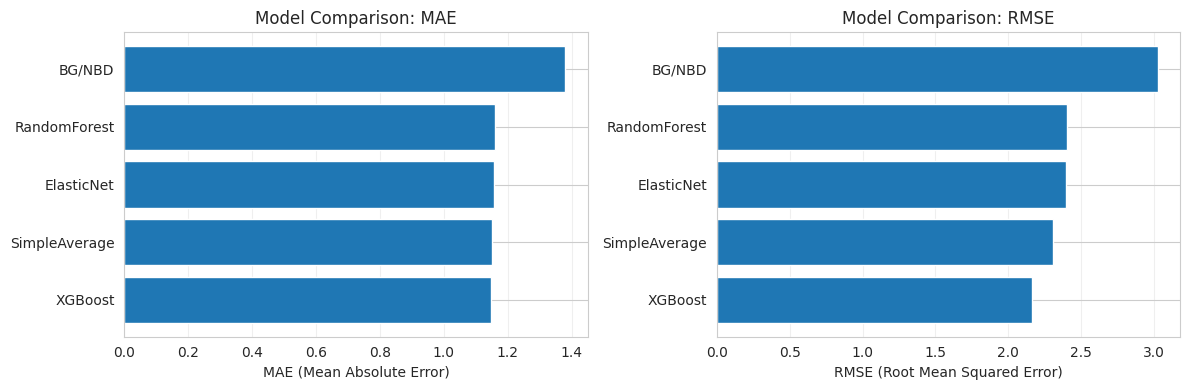

In [16]:
# Visualize comparison
fig = compare_models_plot(results_test_df, save_path='../figures/model_comparison.png')
plt.show()

## 6. Demo Summary

### Checklist for CKPT2 Demo:

✅ **Dataset:** Online Retail II loaded and cleaned (1M+ transactions)  
✅ **EDA:** Visualizations showing customer behavior and temporal patterns  
✅ **Features:** freq, freq_3m, latetime, earlytime implemented  
✅ **Temporal Splits:** Chronological Train/Val/Test (2010/2011)  
✅ **Baselines:** 5 models implemented and evaluated  
✅ **Results:** Complete comparison table with MAE/RMSE  
✅ **Code:** Organized in modular structure (src/)  

### Key Findings:
- All baselines successfully implemented
- Temporal evaluation protocol working
- Ready to proceed with stacking implementation (CKPT3)

### Next Steps:
1. Implement out-of-fold predictions (forward-chaining)
2. Train Level-2 combiner (ElasticNet meta-model)
3. Compare stacking vs baselines
4. Evaluate Config A (pred-only) vs Config B (pred+features)